# 13th video. 벨만 포드(Bellman-Ford) 최단 경로 알고리즘

## 0. 목차
1. 음수 간선이 포함된 상황에서의 최단 거리 문제
2. 벨만 포드 최단 경로 알고리즘
3. 벨만 포드 알고리즘 vs 다익스트라 알고리즘
4. 벨만 포드 알고리즘 소스코드
5. 정리 및 회고

## 1. 음수 간선이 포함된 상황에서의 최단 거리 문제

- BOJ '타임머신' 문제: https://www.acmicpc.net/problem/11657

- N개의 도시가 있다. 그리고 한 도시에서 출발하여 다른 도시에 도착하는 버스 M개가 있다. 각 버스는 A, B, C로 나타낼 수 있는데, A는 시작도시, B는 도착도시, C는 버스를 타고 이동하는데 걸리는 시간이다. 시간 C가 양수가 아닌 경우가 있다. C=0인 경우는 순간 이동을 하는 경우, C < 0인 경우는 타임머신으로 시간을 되돌아가는 경우이다. 1번 도시에서 출발해서 나머지 도시로 가는 가장 빠른 시간을 구하는 프로그램을작성하시오.

- 도시의 개수 : N(1 $\le N \le 500$)
- 버스 노선의 개수 : M(1 \le M \le 6,000)

### 양수 간선만 있는 경우 - 다익스트라 알고리즘

- 모든 간선의 비용이 양수일 때는 다익스트라 최단 경로 알고리즘을 사용하면 된다.
    - 1번 노드에서 다른 노드로 가기 위한 최소 비용은 다음과 같다.

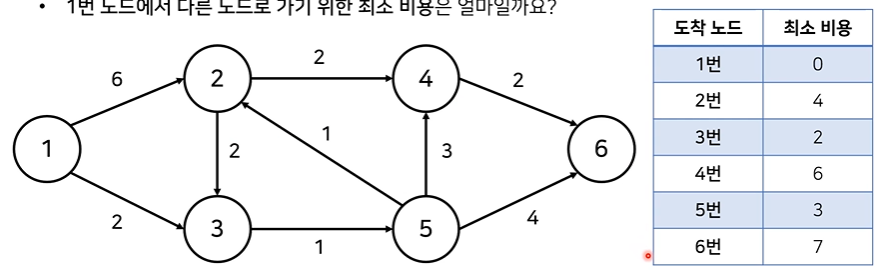

### 음수 간선이 포함된 경우

- 음의 간선이 포함된 경우에도 여전히 최단 거리를 계산할 수 있다.

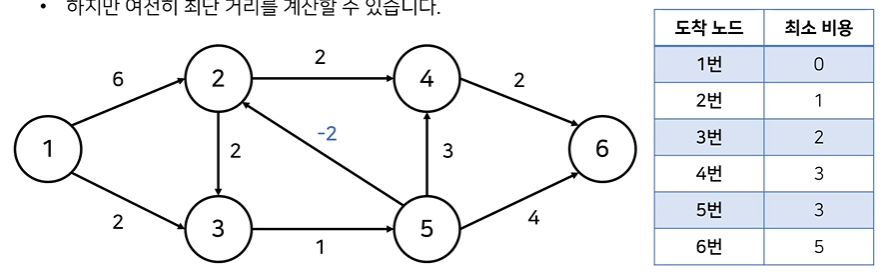

### 음수 간선의 순환이 있는 경우

- 음수 간선의 순환이 포함된 경우에는 최단 거리가 음의 무한인 노드가 발생한다.

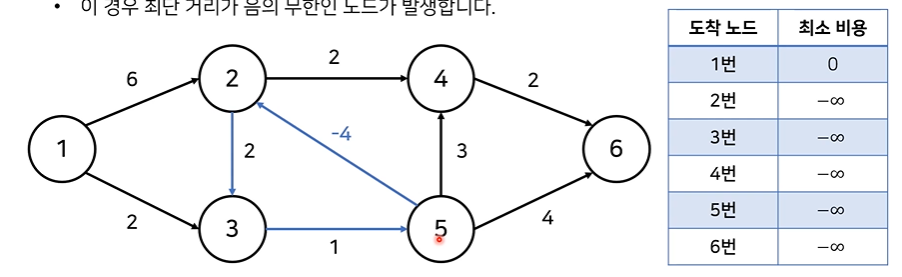


## 2. 벨만 포드 최단 경로 알고리즘

- 음수 간선에 관하여 최단 경로 문제는 다음과 같이 분류할 수 있다.
    1. 모든 간선이 양수인 경우
    2. 음수 간선이 있는 경우
        1) 음수 간선 순환은 없는 경우
        2) 음수 간선 순환ㅇ이 있는 경우

- 벨만 포드 최단 경로 알고리즘은 음의 간선이 포함된 상황에서도 사용할 수 있다.
    - 또한, 으뭇 간선의 순환을 감지할 수 있다.
    - 기본 시간 복잡도는 O(VE)로 다익스트라 알고리즘에 비해 느리다.


- 벨만 포드 알고리즘은 다음과 같아.
    1. 출발 노드를 설정한다.
    2. 최단 거리 테이블을 초기화한다.
    3. 다음의 과정을 N-1번 반복한다.
        1) 전체 간선 E를 하나씩 확인한다.
        2) 각 간선을 거쳐 다른 노드로 가는 비용을 계산하여 최단 거리 테이블을 갱신한다.
- 만약 음수 간선 순환이 발생하는지 체크하고 싶다면 3번의 과정을 한번 더 수행하며 된다. 
    - 이 때 최단 거리 테이블이 갱신된다면 으뭇 간선 순환이 존재하는 것이다.

## 3. 벨만 포드 알고리즘 VS 다익스트라 알고리즘

- 다익스트라 알고리즘
    - 매번 방문하지 않은 노드 중에서 최단 거리가 가장 짧은 노드를 선택한다.
    - 음수 간선이 없다면 최적의 해를 찾을 수 있다.
- 벨만 포드 알고리즘
    - 매번 모든 간선을 전부 확인한다.
        - 따라서 다익스트라 알고리즘에서의 최적의 해를 항상 포함한다.
    - 다익스트라 알고리즘에 비해서 시간이 오래 걸리지만 음수 간선 순환을 탐지할 수 있다.
    
## 4. 벨만 포드 알고리즘 소스코드

```python
import sys
input = sys.stdin.readline
Inf = int(1e9) # 무한을 의미하는 값으로 10억을 설정

def bf(start):
    # 시작 노드에 대해서 초기화
    dist[start] = 0
    for i in range(n):
        # 매 반복마다 "모든 간선"을 확인하며
        for j in range(m):
            cur = edges[j][0]
            next_node = edges[j][1]
            cost = edges[j][2]
            # 현재 간선을 거쳐서 다른 노드로 이동하는 거리가 더 짧은 경우
            if dist[cur] != INF and dist[next_node] > dist[cur] + cost:
                dist[next_node] = dist[cur] + cost
                # n번째 라운드에서도 값이 갱신된다면 음수 순환이 존재
                if i == n - 1:
                    return True
    return False

# 노드의 개수, 간선의 개수를 입력받기
n, m = map(int, input().split())
# 모든 간선에 대한 정보를 담는 리스트 만들기
edges = []
# 최단 거리 테이블을 모두 무한으로 초기화
dist = [INF] * (n + 1)

# 모든 간선 정보를 입력 받기
for _ in range(m):
    a, b, c = map(inet, input().split())
    # a번 노드에서 b번 노드로 가는 비용이 c라는 의미
    edges.append((a, b, c))

# 벨만 포드 알고리즘을 수행
negative_cycle = bf(1) # 1번 노드가 시작 노드

if negative_cycle:
    print("-1")
else:
    # 1번 노드를 제외한 다른 모든 노르드로 가기 위한 최단 거리 출력
    for i in range(2, n+1):
        # 도달할 수 없는 경우, -1을 출력
        if dist[i] == INF:
            print("-1")
        # 도달할 쉬 있는 경우 거리를 출력
        else:
            print(dist[i])
```

## 5. 정리 및 회고

### 순서
1. 음수 간선이 포함된 상황에서의 최단 거리 문제
2. 벨만 포드 최단 경로 알고리즘
3. 벨만 포드 알고리즘 vs 다익스트라 알고리즘
4. 벨만 포드 알고리즘 소스코드
5. 정리 및 회고

### 키워드
벨만 포드 최단 경로 알고리즘, 다익스트라 알고리즘

### 회고 
1. 개인 이슈로 제대로 이해하고 작성하지 X 
2. 따라서, 다시 봐야함.